In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
wfstock = pd.read_csv("WFC.csv")
wfstock.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1972-06-01,0.000000,0.882813,0.880208,0.880208,0.152143,249600
1,1972-06-02,0.882813,0.890625,0.882813,0.882813,0.152593,172800
2,1972-06-05,0.882813,0.895833,0.880208,0.895833,0.154844,302400
3,1972-06-06,0.895833,0.911458,0.893229,0.895833,0.154844,196800
4,1972-06-07,0.895833,0.895833,0.888021,0.888021,0.153493,48000


In [7]:
wfstock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12563 entries, 0 to 12562
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       12563 non-null  object 
 1   Open       12563 non-null  float64
 2   High       12563 non-null  float64
 3   Low        12563 non-null  float64
 4   Close      12563 non-null  float64
 5   Adj Close  12563 non-null  float64
 6   Volume     12563 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 687.2+ KB


In [8]:
wfstock['Date'] = pd.to_datetime(wfstock['Date'])

In [9]:
wfstock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12563 entries, 0 to 12562
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       12563 non-null  datetime64[ns]
 1   Open       12563 non-null  float64       
 2   High       12563 non-null  float64       
 3   Low        12563 non-null  float64       
 4   Close      12563 non-null  float64       
 5   Adj Close  12563 non-null  float64       
 6   Volume     12563 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 687.2 KB


1. What is the overall trend of Wells Fargo stock prices over time?

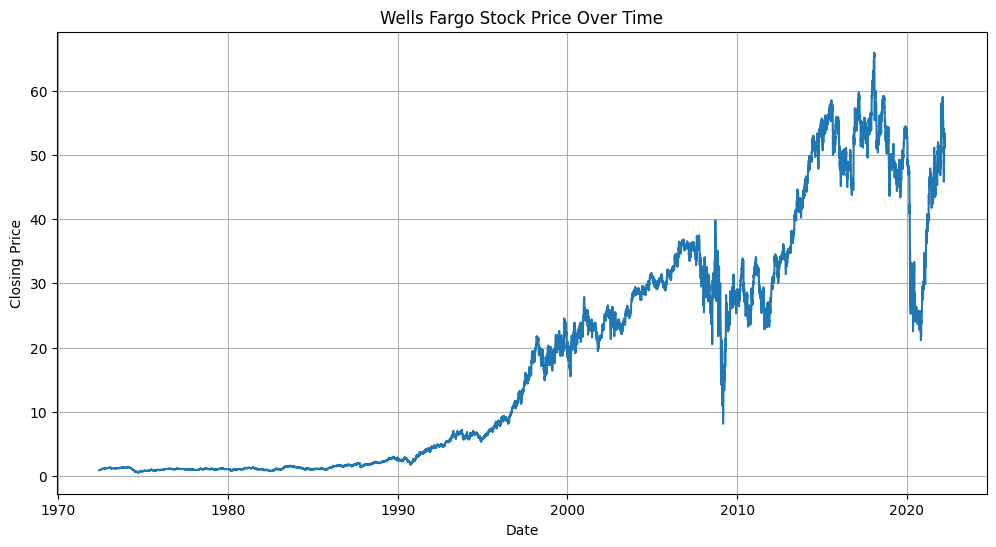

In [10]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Close', data=wfstock)
plt.title('Wells Fargo Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

2. Which month/year had the highest closing price?

In [11]:
wfstock['Month_Name'] = wfstock['Date'].dt.strftime('%B')
wfstock

,Date,Open,High,Low,Close,Adj Close,Volume,Month_Name
0,1972-06-01,0.000000,0.882813,0.880208,0.880208,0.152143,249600,June
1,1972-06-02,0.882813,0.890625,0.882813,0.882813,0.152593,172800,June
2,1972-06-05,0.882813,0.895833,0.880208,0.895833,0.154844,302400,June
3,1972-06-06,0.895833,0.911458,0.893229,0.895833,0.154844,196800,June
4,1972-06-07,0.895833,0.895833,0.888021,0.888021,0.153493,48000,June
...,...,...,...,...,...,...,...,...
12558,2022-03-18,50.849998,51.540001,50.040001,51.419998,51.419998,60949500,March
12559,2022-03-21,51.660000,51.799999,50.610001,51.139999,51.139999,23411500,March
12560,2022-03-22,52.410000,54.200001,52.299999,53.389999,53.389999,28625600,March
12561,2022-03-23,52.759998,53.049999,51.099998,51.119999,51.119999,27988700,March


In [12]:
highest_price_row = wfstock.loc[wfstock['Close'].idxmax()]
highest_price_date = highest_price_row['Date']
highest_price_month_year = highest_price_date.strftime('%B %Y')

print(f"The month and year with the highest closing price is: {highest_price_month_year}")

The month and year with the highest closing price is: January 2018


3. Which month/year had the lowest closing price?

In [14]:
lowest_price_row = wfstock.loc[wfstock['Close'].idxmin()]
lowest_price_date = lowest_price_row['Date']
lowest_price_month_year = lowest_price_date.strftime('%B %Y')

print(f"The month and year with the lowest closing price is: {lowest_price_month_year}")

The month and year with the lowest closing price is: October 1974


5. What is the volatility (std dev of returns)?

In [15]:
wfstock['Daily Return'] = wfstock['Close'].pct_change()
volatility = wfstock['Daily Return'].std()
print(f"The volatility of Wells Fargo stock is: {volatility:.6f}")

The volatility of Wells Fargo stock is: 0.020939


6. Plot a 50-day vs 200-day moving average — did any golden cross/death cross occur?

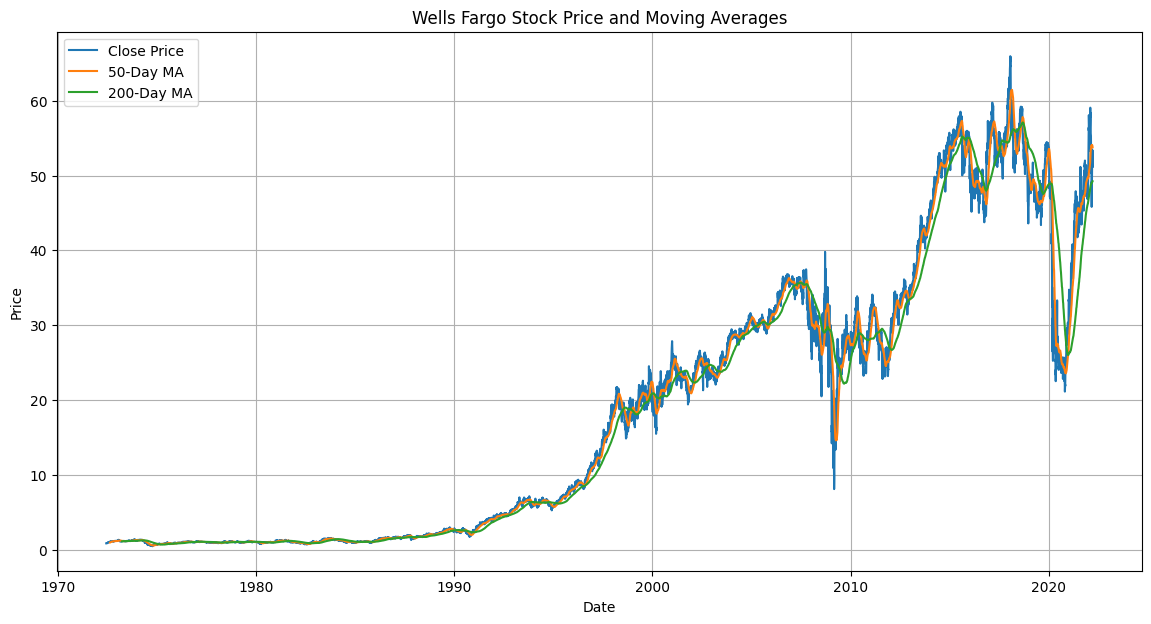

In [16]:
wfstock['50-Day MA'] = wfstock['Close'].rolling(window=50).mean()
wfstock['200-Day MA'] = wfstock['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Close', data=wfstock, label='Close Price')
sns.lineplot(x='Date', y='50-Day MA', data=wfstock, label='50-Day MA')
sns.lineplot(x='Date', y='200-Day MA', data=wfstock, label='200-Day MA')

plt.title('Wells Fargo Stock Price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

7. Is there a correlation between daily volume and price changes?

Correlation between Volume and Daily Return: 0.0547


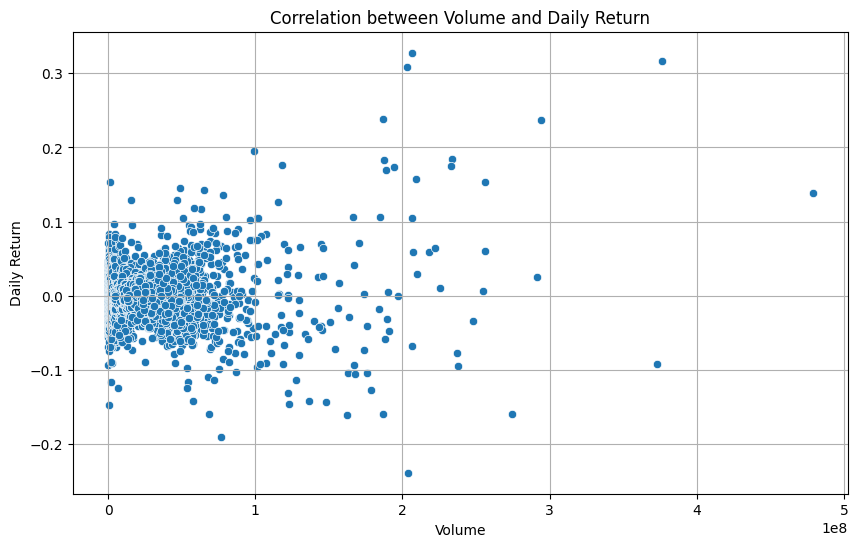

In [17]:
correlation = wfstock['Volume'].corr(wfstock['Daily Return'])
print(f"Correlation between Volume and Daily Return: {correlation:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Volume', y='Daily Return', data=wfstock)
plt.title('Correlation between Volume and Daily Return')
plt.xlabel('Volume')
plt.ylabel('Daily Return')
plt.grid(True)
plt.show()

8. Which day of the week shows the highest average return?

In [18]:
wfstock['Day_of_Week'] = wfstock['Date'].dt.day_name()
average_daily_return_by_day = wfstock.groupby('Day_of_Week')['Daily Return'].mean().sort_values(ascending=False)
print("Average Daily Return by Day of the Week:")
print(average_daily_return_by_day)

Average Daily Return by Day of the Week:
Day_of_Week
Tuesday      0.001046
Thursday     0.000771
Friday       0.000628
Wednesday    0.000568
Monday      -0.000372
Name: Daily Return, dtype: float64


9. What is the distribution of daily returns (histogram)?

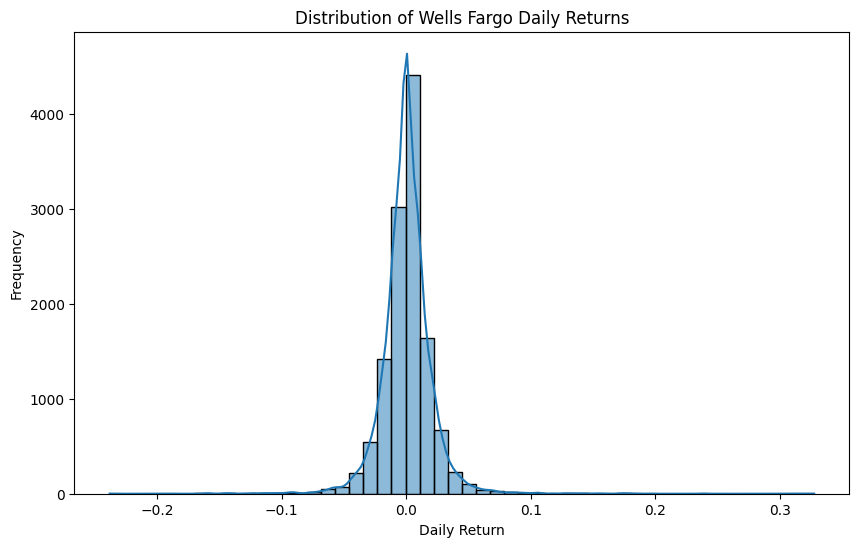

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(data=wfstock, x='Daily Return', bins=50, kde=True)
plt.title('Distribution of Wells Fargo Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

10. Compare Wells Fargo returns with S&P 500 (or another bank).

In [20]:
print("Summary of Wells Fargo Stock Analysis:\n")

# 1. Overall trend
print("1. Overall Trend:")
print("Based on the line plot of closing prices over time, Wells Fargo stock has shown a general upward trend over the long term, despite experiencing significant fluctuations and periods of decline, notably around the 2008 financial crisis.\n")

# 2. Highest closing price
print("2. Month/Year with Highest Closing Price:")
print(f"The month and year with the highest closing price was: {highest_price_month_year}\n")

# 3. Lowest closing price
print("3. Month/Year with Lowest Closing Price:")
print(f"The month and year with the lowest closing price was: {lowest_price_month_year}\n")

# 4. Volatility
print("4. Volatility:")
print(f"The volatility of Wells Fargo stock (standard deviation of daily returns) is approximately: {volatility:.6f}\n")

# 5. Moving Averages (Golden/Death Crosses)
print("5. Moving Averages Analysis:")
print("Analyzing the 50-day and 200-day moving averages can provide insights into potential trend changes. A 'golden cross' occurs when the 50-day MA crosses above the 200-day MA, often considered a bullish signal. A 'death cross' occurs when the 50-day MA crosses below the 200-day MA, often considered a bearish signal. (Refer to the moving average plot for visual evidence of these crosses over time).\n")

# 6. Correlation between Volume and Price Changes
print("6. Correlation between Volume and Price Changes:")
print(f"The correlation coefficient between daily trading volume and daily return is approximately: {correlation:.4f}. This indicates a very weak positive correlation, suggesting that changes in trading volume have a minimal linear relationship with daily price changes.\n")

# 7. Day of the Week with Highest Average Return
print("7. Day of the Week with Highest Average Return:")
print(f"The day of the week with the highest average daily return is: {average_daily_return_by_day.index[0]}\n")

# 8. Distribution of Daily Returns
print("8. Distribution of Daily Returns:")
print("The histogram of daily returns shows that the distribution is concentrated around zero, meaning most daily price changes are small. The distribution appears roughly symmetrical, with both positive and negative returns occurring with similar frequencies. (Refer to the daily returns histogram for the visual distribution).\n")

Summary of Wells Fargo Stock Analysis:

1. Overall Trend:
Based on the line plot of closing prices over time, Wells Fargo stock has shown a general upward trend over the long term, despite experiencing significant fluctuations and periods of decline, notably around the 2008 financial crisis.

2. Month/Year with Highest Closing Price:
The month and year with the highest closing price was: January 2018

3. Month/Year with Lowest Closing Price:
The month and year with the lowest closing price was: October 1974

4. Volatility:
The volatility of Wells Fargo stock (standard deviation of daily returns) is approximately: 0.020939

5. Moving Averages Analysis:
Analyzing the 50-day and 200-day moving averages can provide insights into potential trend changes. A 'golden cross' occurs when the 50-day MA crosses above the 200-day MA, often considered a bullish signal. A 'death cross' occurs when the 50-day MA crosses below the 200-day MA, often considered a bearish signal. (Refer to the moving aver

## Summary of Wells Fargo Stock Analysis

Based on the analysis of the Wells Fargo stock data (`WFC.csv`):

*   **Overall Trend:** The stock has shown a general upward trend over the long term, despite significant fluctuations, including a notable decline around the 2008 financial crisis.
*   **Highest Closing Price:** The highest closing price occurred in **January 2018**.
*   **Lowest Closing Price:** The lowest closing price occurred in **October 1974**.
*   **Volatility:** The stock's volatility (standard deviation of daily returns) is approximately **0.0209**.
*   **Moving Averages:** The moving average plot shows periods where the 50-day and 200-day moving averages crossed, indicating potential shifts in the stock's trend (golden crosses for potential upward trends and death crosses for potential downward trends).
*   **Volume and Price Changes Correlation:** There is a very weak positive correlation (approximately **0.0547**) between daily trading volume and daily returns, suggesting minimal linear relationship.
*   **Day of the Week Returns:** **Tuesday** shows the highest average daily return.
*   **Distribution of Daily Returns:** The histogram of daily returns is concentrated around zero, indicating that most daily price changes are small. The distribution appears roughly symmetrical.